# **Business Analytics for Public Safety: Predicting Homicide Patterns in Toronto**

# **Business Analytics Course: Milestone 2**

Install Required Libraries

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings("ignore")

Load the Dataset

In [ ]:
df = pd.read_csv("/content/Homicides.csv")
df.head()

,OBJECTID,EVENT_UNIQUE_ID,OCC_DATE,OCC_YEAR,OCC_MONTH,OCC_DAY,OCC_DOW,OCC_DOY,DIVISION,HOMICIDE_TYPE,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y
0,1,GO-2004111878,1/3/2004 5:00:00 AM,2004,January,3,Saturday,3,D53,Other,098,Rosedale-Moore Park (98),098,Rosedale-Moore Park (98),-79.392828,43.685026,-8.837969e+06,5.416828e+06
1,2,GO-2004136086,1/8/2004 5:00:00 AM,2004,January,8,Thursday,8,D42,Shooting,146,Malvern East (146),132,Malvern (132),-79.205574,43.810544,-8.817124e+06,5.436170e+06
2,3,GO-2004125755,1/8/2004 5:00:00 AM,2004,January,8,Thursday,8,D42,Shooting,142,Woburn North (142),137,Woburn (137),-79.233852,43.781782,-8.820272e+06,5.431734e+06
3,4,GO-2004148619,1/25/2004 5:00:00 AM,2004,January,25,Sunday,25,D42,Shooting,144,Morningside Heights (144),131,Rouge (131),-79.204958,43.822997,-8.817056e+06,5.438091e+06
4,5,GO-2004148623,1/25/2004 5:00:00 AM,2004,January,25,Sunday,25,D13,Shooting,171,Junction-Wallace Emerson (171),093,Dovercourt-Wallace Emerson-Junction (93),-79.434387,43.670467,-8.842596e+06,5.414587e+06


Basic Data Understanding

In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (1526, 18)

Columns:
Index(['OBJECTID', 'EVENT_UNIQUE_ID', 'OCC_DATE', 'OCC_YEAR', 'OCC_MONTH',
       'OCC_DAY', 'OCC_DOW', 'OCC_DOY', 'DIVISION', 'HOMICIDE_TYPE',
       'HOOD_158', 'NEIGHBOURHOOD_158', 'HOOD_140', 'NEIGHBOURHOOD_140',
       'LONG_WGS84', 'LAT_WGS84', 'x', 'y'],
      dtype='object')

Missing Values:
OBJECTID             0
EVENT_UNIQUE_ID      0
OCC_DATE             0
OCC_YEAR             0
OCC_MONTH            0
OCC_DAY              0
OCC_DOW              0
OCC_DOY              0
DIVISION             0
HOMICIDE_TYPE        0
HOOD_158             0
NEIGHBOURHOOD_158    0
HOOD_140             0
NEIGHBOURHOOD_140    0
LONG_WGS84           0
LAT_WGS84            0
x                    0
y                    0
dtype: int64


# Data Cleaning

In [ ]:
# Remove duplicates
df = df.drop_duplicates()

# Convert OCC_DATE to datetime
df['OCC_DATE'] = pd.to_datetime(df['OCC_DATE'])

print("Shape after cleaning:", df.shape)

Shape after cleaning: (1526, 18)


Drop Unnecessary Columns

In [ ]:
df = df.drop(columns=[
    'OBJECTID',
    'EVENT_UNIQUE_ID',
    'HOOD_140',
    'NEIGHBOURHOOD_140',
    'x', 'y'])

df.head()

,OCC_DATE,OCC_YEAR,OCC_MONTH,OCC_DAY,OCC_DOW,OCC_DOY,DIVISION,HOMICIDE_TYPE,HOOD_158,NEIGHBOURHOOD_158,LONG_WGS84,LAT_WGS84
0,2004-01-03 05:00:00,2004,January,3,Saturday,3,D53,Other,098,Rosedale-Moore Park (98),-79.392828,43.685026
1,2004-01-08 05:00:00,2004,January,8,Thursday,8,D42,Shooting,146,Malvern East (146),-79.205574,43.810544
2,2004-01-08 05:00:00,2004,January,8,Thursday,8,D42,Shooting,142,Woburn North (142),-79.233852,43.781782
3,2004-01-25 05:00:00,2004,January,25,Sunday,25,D42,Shooting,144,Morningside Heights (144),-79.204958,43.822997
4,2004-01-25 05:00:00,2004,January,25,Sunday,25,D13,Shooting,171,Junction-Wallace Emerson (171),-79.434387,43.670467


Columns such as OBJECTID and EVENT_UNIQUE_ID were removed as they represent unique identifiers and do not contribute predictive value. Additionally, redundant spatial and neighbourhood representations (HOOD_140 and x/y coordinates) were excluded to reduce multicollinearity and improve model efficiency.

# Exploratory Data Analysis (EDA)

## **Chart 1 — Annual Homicide Trend in Toronto**
Homicides by Year

Shows trend over time

Business insight: rising trend in recent years


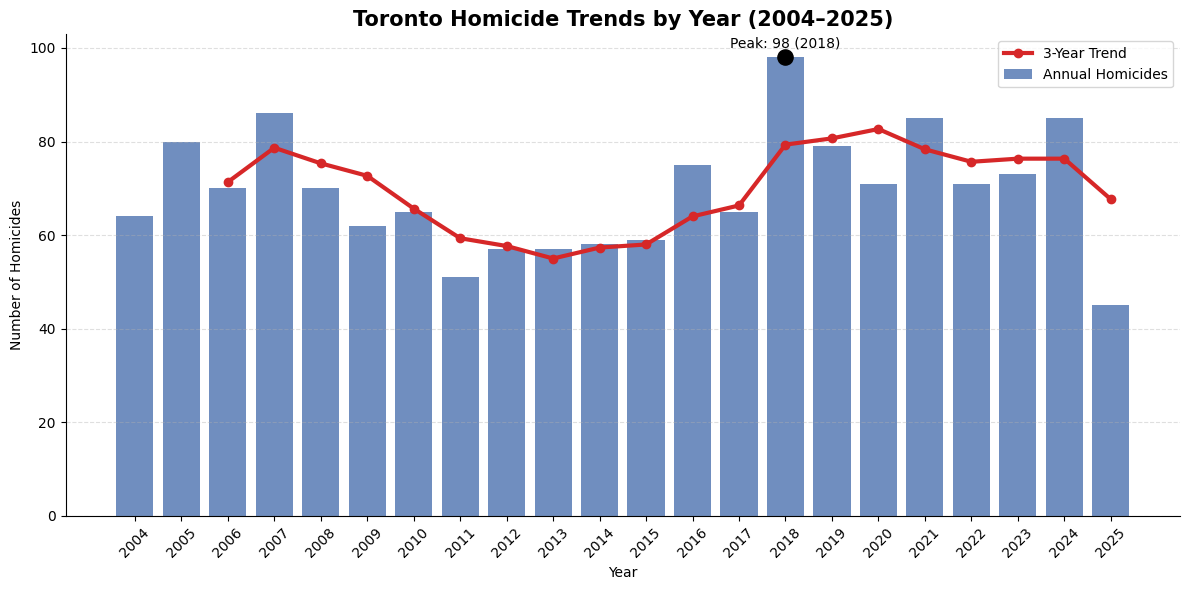

In [ ]:
# Chart 1 — Annual Homicide Trend Analysis

# Aggregate homicides per year
yearly_counts = df.groupby("OCC_YEAR").size().reset_index(name="HOMICIDE_TOTAL")

# Calculate moving average to show trend
yearly_counts["TREND"] = yearly_counts["HOMICIDE_TOTAL"].rolling(3).mean()

plt.figure(figsize=(12,6))

# Bar chart
plt.bar(
    yearly_counts["OCC_YEAR"],
    yearly_counts["HOMICIDE_TOTAL"],
    color="#4C72B0",
    alpha=0.8,
    label="Annual Homicides"
)

# Trend line
plt.plot(
    yearly_counts["OCC_YEAR"],
    yearly_counts["TREND"],
    color="#D62728",
    linewidth=3,
    marker="o",
    label="3-Year Trend"
)

# Highlight peak year
peak_row = yearly_counts.loc[yearly_counts["HOMICIDE_TOTAL"].idxmax()]

plt.scatter(
    peak_row["OCC_YEAR"],
    peak_row["HOMICIDE_TOTAL"],
    color="black",
    s=120,
    zorder=5
)

plt.text(
    peak_row["OCC_YEAR"],
    peak_row["HOMICIDE_TOTAL"] + 2,
    f"Peak: {int(peak_row['HOMICIDE_TOTAL'])} ({int(peak_row['OCC_YEAR'])})",
    ha="center",
    fontsize=10
)

plt.title(
    "Toronto Homicide Trends by Year (2004–2025)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Number of Homicides")

plt.xticks(yearly_counts["OCC_YEAR"], rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend()
sns.despine()

plt.tight_layout()
plt.show()

CHART 1:

Between 2004 and 2025, Toronto recorded 1526 homicide incidents,
with an average of approximately 69 cases per year.

The visualization shows noticeable fluctuations over time, with the highest
recorded level occurring in 2018. The trend line
suggests a gradual increase in homicide activity in more recent years,
indicating a growing need for proactive public safety strategies and
data-driven policing initiatives.

# **Chart 2 Neighbourhood Risk Analysis (Spatial pattern)**

For public safety analytics, a this chart shows:

Top neighbourhoods with highest homicide counts

This helps Toronto Police allocate resources geographically.

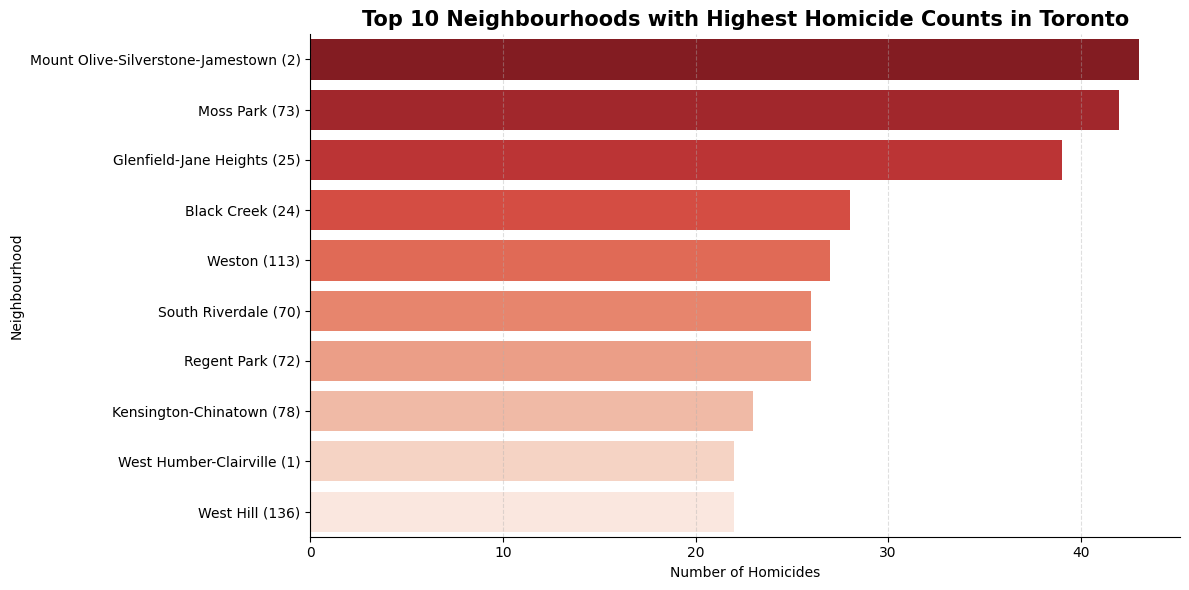

In [ ]:
# Chart 2 — Top Neighbourhoods with Highest Homicide Counts

top_neigh = (
    df.groupby("NEIGHBOURHOOD_158")
      .size()
      .reset_index(name="COUNT")
      .sort_values("COUNT", ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_neigh,
    y="NEIGHBOURHOOD_158",
    x="COUNT",
    palette="Reds_r"
)

plt.title(
    "Top 10 Neighbourhoods with Highest Homicide Counts in Toronto",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Number of Homicides")
plt.ylabel("Neighbourhood")

plt.grid(axis="x", linestyle="--", alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()


CHART 2:

Neighbourhood-level analysis shows strong geographic concentration of homicide
incidents in Toronto. The neighbourhood with the highest recorded homicides is
Mount Olive-Silverstone-Jamestown (2) with 43 incidents during the study period.

The top 10 neighbourhoods collectively account for a large share of total
incidents, suggesting that targeted policing strategies, community programs,
and prevention initiatives in these areas could significantly reduce overall
crime levels in the city.

# **Chart 3 Homicide Type Distribution**

For public safety analytics, a this chart shows:

Shows the breakdown of homicide types (Shooting, Stabbing, Other)

Business insight: Shootings dominate - informs resource allocation

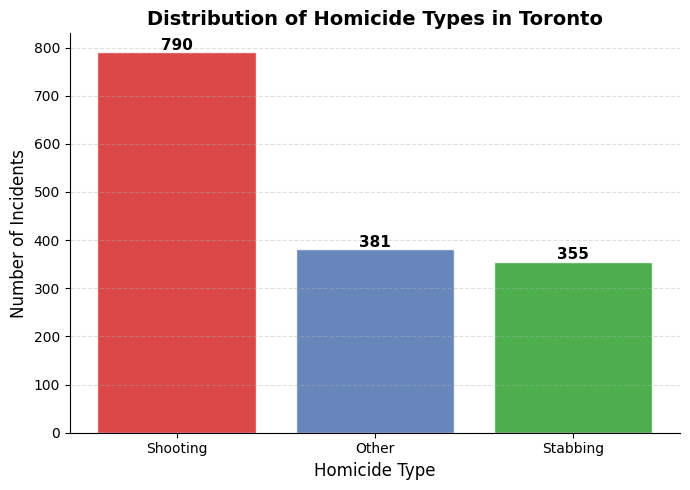

In [ ]:
type_counts = df['HOMICIDE_TYPE'].value_counts().reset_index()
type_counts.columns = ['HOMICIDE_TYPE', 'COUNT']

plt.figure(figsize=(7, 5))

bars = plt.bar(
    type_counts['HOMICIDE_TYPE'],
    type_counts['COUNT'],
    color=['#D62728', '#4C72B0', '#2CA02C'],
    alpha=0.85,
    edgecolor='white')

# Add count labels on top of bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(int(bar.get_height())),
        ha='center',
        fontsize=11,
        fontweight='bold')

plt.title("Distribution of Homicide Types in Toronto",
    fontsize=14,
    fontweight="bold")

plt.xlabel("Homicide Type", fontsize=12)
plt.ylabel("Number of Incidents", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

CHART 3:

Analysis of homicide methods reveals imbalance in the dataset, with Shootings accounting for nearly half of all recorded incidents (over 700 cases). This is followed by Stabbings and Other methods, which include blunt force trauma and other forms of physical assault.

Understanding this distribution is vital for predictive modeling; because "Shootings" are the majority class, the classification model must be evaluated using Precision and Recall rather than just Accuracy. From a policy perspective, these findings emphasize that firearm-related violence remains the most critical area for public safety intervention and legislative focus in Toronto.

# **Chart 4 Homicide Count by Day of Week**

For public safety analytics, a this chart shows:

Shows which days see the most homicides

Business insight: weekends (Fri–Sun) are peak days

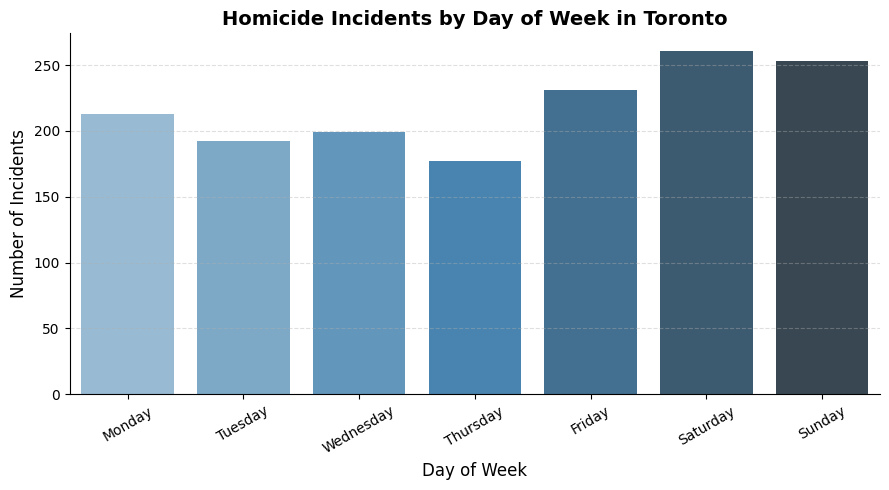

In [ ]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

dow_counts = (
    df.groupby('OCC_DOW')
      .size()
      .reindex(day_order)
      .reset_index(name='COUNT'))

plt.figure(figsize=(9, 5))

sns.barplot(
    data=dow_counts,
    x='OCC_DOW',
    y='COUNT',
    palette='Blues_d')

plt.title(
    "Homicide Incidents by Day of Week in Toronto",
    fontsize=14,
    fontweight="bold")

plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Number of Incidents", fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

CHART 4:

The analysis of homicide distribution by day of the week shows a relatively high frequency of incidents on Saturdays and Mondays, while Thursdays recorded the lowest number of incidents during this study period.

The high volume on Saturdays aligns with typical weekend patterns involving increased social gatherings. However, the spike on Mondays is a critical finding, as it may reflect incidents occurring late Sunday night being reported or finalized on Monday morning. From a business analytics perspective, this suggests that high-risk periods are not limited to the traditional weekend, and law enforcement staffing should remain at peak levels through the start of the work week to effectively manage this trend.

# **Chart 5 Homicide by Month**

For public safety analytics, a this chart shows:

Shows which months see the most homicides


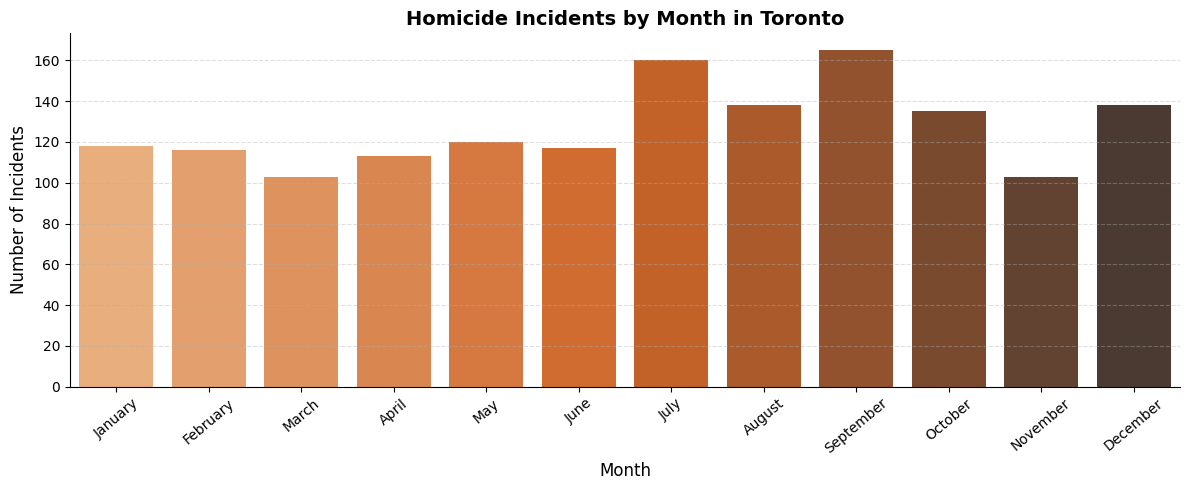

In [ ]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

month_counts = (
    df.groupby('OCC_MONTH')
      .size()
      .reindex(month_order)
      .reset_index(name='COUNT')
)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=month_counts,
    x='OCC_MONTH',
    y='COUNT',
    palette='Oranges_d'
)

plt.title("Homicide Incidents by Month in Toronto",
          fontsize=14, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Incidents", fontsize=12)
plt.xticks(rotation=40)
plt.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

Chart 5:

The monthly distribution of homicides highlights a clear seasonal pattern, with incident counts rising significantly during the Summer months (July and August). This peak suggests that warmer weather and increased outdoor social activity are correlated with higher crime rates in Toronto.

From a resource management perspective, this trend provides actionable intelligence for the Toronto Police Service, indicating that peak enforcement and community outreach efforts should be strategically concentrated during the third quarter of the year to address this consistent seasonal surge.

# **Chart 6 Homicides by Police Division**

For public safety analytics, a this chart shows:

Shows which Division see the most homicides


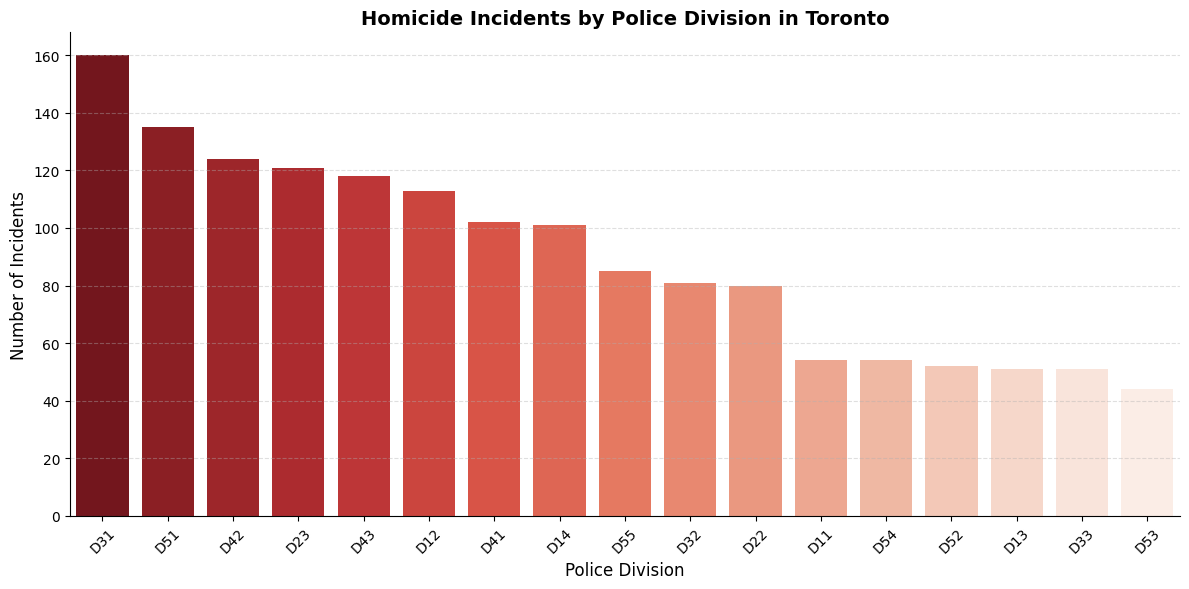

In [ ]:
division_counts = (
    df.groupby('DIVISION')
      .size()
      .reset_index(name='COUNT')
      .sort_values('COUNT', ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=division_counts,
    x='DIVISION',
    y='COUNT',
    palette='Reds_r'
)

plt.title("Homicide Incidents by Police Division in Toronto",
          fontsize=14, fontweight='bold')
plt.xlabel("Police Division", fontsize=12)
plt.ylabel("Number of Incidents", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

Chart 6:

This chart highlights a significant disparity in incident volume across different Toronto Police Divisions. Division D31 recorded the highest number of homicides (160), followed closely by D51 and D42. In contrast, divisions like D53 and D33 show substantially lower incident rates.

This uneven distribution confirms that violent crime is not spread uniformly across the city, but is instead concentrated in specific jurisdictions.This finding is crucial because it validates "Division" as a key categorical feature for the model, suggesting that the administrative boundaries used by law enforcement align closely with the geographic "hotspots" identified in the earlier spatial analysis.

# **Chart 7: Homicide Type Over Time**



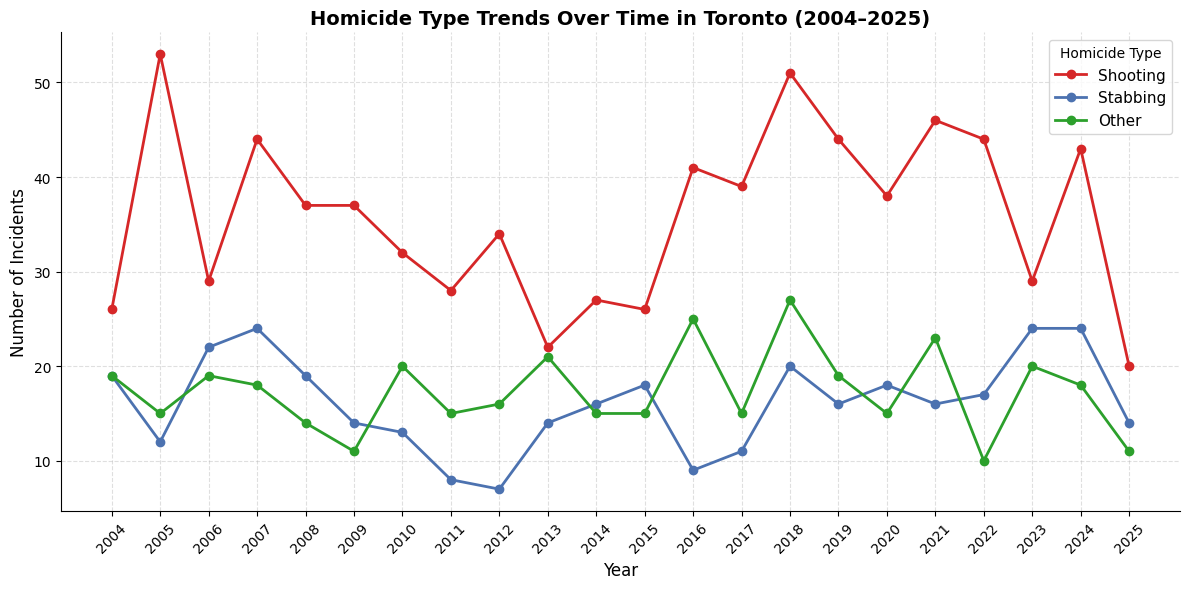

In [ ]:
type_year = (
    df.groupby(['OCC_YEAR', 'HOMICIDE_TYPE'])
      .size()
      .reset_index(name='COUNT')
)

plt.figure(figsize=(12, 6))

for htype, color in zip(['Shooting', 'Stabbing', 'Other'], ['#D62728', '#4C72B0', '#2CA02C']):
    subset = type_year[type_year['HOMICIDE_TYPE'] == htype]
    plt.plot(
        subset['OCC_YEAR'],
        subset['COUNT'],
        marker='o',
        linewidth=2,
        label=htype,
        color=color
    )

plt.title("Homicide Type Trends Over Time in Toronto (2004–2025)",
          fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Incidents", fontsize=12)
plt.xticks(type_year['OCC_YEAR'].unique(), rotation=45)
plt.legend(title="Homicide Type", fontsize=11)
plt.grid(linestyle="--", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

CHART 7:

Shootings have consistently been the dominant homicide type throughout
2004–2025, with notable spikes in 2005 and 2018. Stabbings and "Other"
types remained relatively stable over the same period, showing no
significant upward or downward trend.

The elevated shooting levels from 2016 onward suggest that gun violence
prevention should remain a priority for Toronto Police resource allocation.

# Feature Engineering

In [ ]:
df_model = df[[
    'HOMICIDE_TYPE',
    'DIVISION',
    'NEIGHBOURHOOD_158',
    'OCC_YEAR', 'OCC_MONTH',
    'OCC_DOW', 'LAT_WGS84',
    'LONG_WGS84']]

df_model.head()

,HOMICIDE_TYPE,DIVISION,NEIGHBOURHOOD_158,OCC_YEAR,OCC_MONTH,OCC_DOW,LAT_WGS84,LONG_WGS84
0,Other,D53,Rosedale-Moore Park (98),2004,January,Saturday,43.685026,-79.392828
1,Shooting,D42,Malvern East (146),2004,January,Thursday,43.810544,-79.205574
2,Shooting,D42,Woburn North (142),2004,January,Thursday,43.781782,-79.233852
3,Shooting,D42,Morningside Heights (144),2004,January,Sunday,43.822997,-79.204958
4,Shooting,D13,Junction-Wallace Emerson (171),2004,January,Sunday,43.670467,-79.434387


# CLASSIFICATION PROBLEM

Predict Homicide Type

Encode Categorical Variables

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()
le_div = LabelEncoder()
le_neigh = LabelEncoder()

df_model['HOMICIDE_TYPE_ENC'] = le_target.fit_transform(df_model['HOMICIDE_TYPE'])
df_model['DIVISION_ENC'] = le_div.fit_transform(df_model['DIVISION'])
df_model['NEIGHBOURHOOD_ENC'] = le_neigh.fit_transform(df_model['NEIGHBOURHOOD_158'])

Define Features & Target

In [ ]:
X = df_model[[
    'DIVISION_ENC',
    'NEIGHBOURHOOD_ENC',
    'OCC_YEAR',
    'OCC_MONTH',
    'OCC_DOW',
    'LAT_WGS84',
    'LONG_WGS84'
]]

y = df_model['HOMICIDE_TYPE_ENC']

Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Baseline Model (Zero Rule)

Predicts the most frequent class for every instance

In [ ]:
from collections import Counter

most_common_class = Counter(y_train).most_common(1)[0][0]
y_pred_baseline = [most_common_class] * len(y_test)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline (most-frequent class) Accuracy: {baseline_accuracy:.4f}")
print(f"Most frequent class (encoded):{most_common_class} → '{le_target.inverse_transform([most_common_class])[0]}'")

Baseline (most-frequent class) Accuracy: 0.5425
Most frequent class (encoded):1 → 'Shooting'


We established a "Most-Frequent Class" baseline by predicting every incident as a 'Shooting,' which yielded an accuracy of 54.25%. This serves as our performance floor; for any advanced machine learning model (such as Random Forest) to be considered effective, it must significantly outperform this 54.25% threshold by correctly identifying the less frequent "Stabbing" and "Other" categories.

# MODEL 1 — Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Create copies to avoid modifying original X_train, X_test if they are reused later
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

# Initialize LabelEncoders for 'OCC_MONTH' and 'OCC_DOW'
le_month = LabelEncoder()
le_dow = LabelEncoder()

# Fit and transform 'OCC_MONTH' and 'OCC_DOW' in X_train_processed
X_train_processed['OCC_MONTH'] = le_month.fit_transform(X_train_processed['OCC_MONTH'])
X_train_processed['OCC_DOW'] = le_dow.fit_transform(X_train_processed['OCC_DOW'])

# Transformed 'OCC_MONTH' and 'OCC_DOW' in X_test_processed using the fitted encoders
X_test_processed['OCC_MONTH'] = le_month.transform(X_test_processed['OCC_MONTH'])
X_test_processed['OCC_DOW'] = le_dow.transform(X_test_processed['OCC_DOW'])

dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train_processed, y_train)

y_pred_dt = dt.predict(X_test_processed)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.5163398692810458
              precision    recall  f1-score   support

           0       0.15      0.04      0.06        76
           1       0.56      0.93      0.70       166
           2       0.08      0.02      0.03        64

    accuracy                           0.52       306
   macro avg       0.27      0.33      0.26       306
weighted avg       0.36      0.52      0.40       306



## K-Fold Cross-Vlidation for Decision Tree

We apply 5-fold stratified cross-validation to the final Decision Tree on the full dataset. If the CV score is close to the test accuracy the model generalises well and is not overfitting to the 80% training split.

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# Full feature matrix — same encoding as Model 1
X_cv_dt = df_model[[
    'DIVISION_ENC', 'NEIGHBOURHOOD_ENC',
    'OCC_YEAR', 'OCC_MONTH', 'OCC_DOW',
    'LAT_WGS84', 'LONG_WGS84'
]].copy()

from sklearn.preprocessing import LabelEncoder
le_month_cv = LabelEncoder()
le_dow_cv   = LabelEncoder()
X_cv_dt['OCC_MONTH'] = le_month_cv.fit_transform(X_cv_dt['OCC_MONTH'])
X_cv_dt['OCC_DOW']   = le_dow_cv.fit_transform(X_cv_dt['OCC_DOW'])
y_cv = df_model['HOMICIDE_TYPE_ENC']

# 5-Fold Stratified CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
dt_final_cv = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_cv_scores = cross_val_score(dt_final_cv, X_cv_dt, y_cv, cv=skf, scoring='accuracy')

print('Decision Tree — 5-Fold CV Accuracy per fold:', np.round(dt_cv_scores, 4))
print(f'Mean CV Accuracy : {dt_cv_scores.mean():.4f}')
print(f'Std  CV Accuracy : {dt_cv_scores.std():.4f}')
print(f'Test Accuracy    : {accuracy_score(y_test, y_pred_dt):.4f}')
gap = abs(dt_cv_scores.mean() - accuracy_score(y_test, y_pred_dt))
print()
if gap < 0.03:
    print('CV and test accuracy are close, model generalises well (no significant overfitting).')
else:
    print('Gap between CV and test accuracy, possible overfitting or high data variance.')


Decision Tree — 5-Fold CV Accuracy per fold: [0.4804 0.4852 0.5115 0.4918 0.4754]
Mean CV Accuracy : 0.4889
Std  CV Accuracy : 0.0125
Test Accuracy    : 0.5163

CV and test accuracy are close, model generalises well (no significant overfitting).


- Consistency Across Folds: The 5-Fold Cross-Validation yielded a mean accuracy of 48.89% with a very low standard deviation (0.0125). This indicates that the model's performance is stable and not dependent on a specific subset of the data.

- Strong Generalization: The small gap between the Mean CV Accuracy (48.89%) and the Test Accuracy (51.63%) confirms that the model is generalizing well to unseen data.

- Bias-Variance Balance: Because the test performance is slightly higher than the average CV performance, we can conclude there is no significant overfitting (where the model memorizes noise) or underfitting (where the model is too simple to learn).

# Parameter Tuning for Decision Tree

Shows how accuracy changes as we vary max_depth

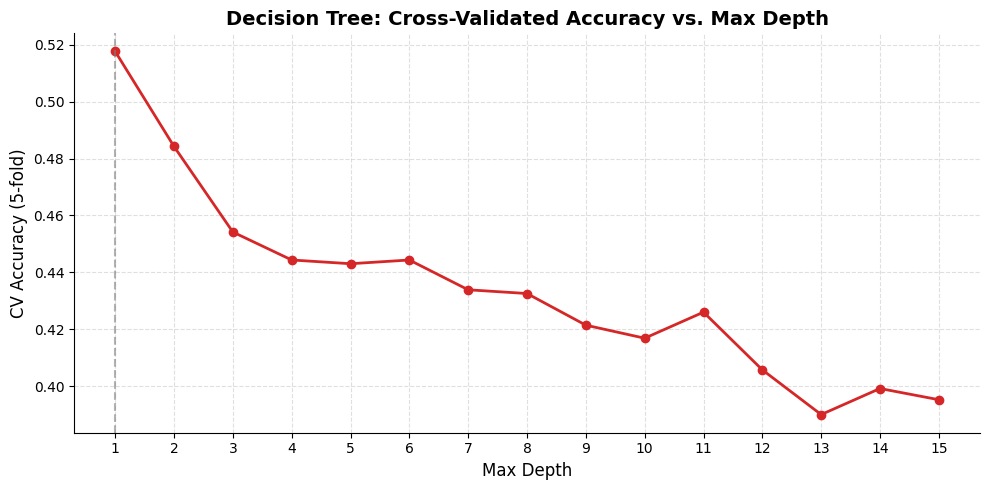

Best max_depth: 1 → CV Accuracy: 0.5177


In [ ]:
from sklearn.model_selection import cross_val_score

# Encode OCC_MONTH and OCC_DOW once for the full feature matrix
from sklearn.preprocessing import LabelEncoder

X_tuning = df_model[[
    'DIVISION_ENC',
    'NEIGHBOURHOOD_ENC',
    'OCC_YEAR',
    'OCC_MONTH',
    'OCC_DOW',
    'LAT_WGS84',
    'LONG_WGS84'
]].copy()

le_month_t = LabelEncoder()
le_dow_t = LabelEncoder()
X_tuning['OCC_MONTH'] = le_month_t.fit_transform(X_tuning['OCC_MONTH'])
X_tuning['OCC_DOW'] = le_dow_t.fit_transform(X_tuning['OCC_DOW'])

y_tuning = df_model['HOMICIDE_TYPE_ENC']

depths = range(1, 16)
cv_scores = []

for d in depths:
    dt_temp = DecisionTreeClassifier(max_depth=d, random_state=42)
    scores = cross_val_score(dt_temp, X_tuning, y_tuning, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

plt.figure(figsize=(10, 5))
plt.plot(depths, cv_scores, marker='o', color='#D62728', linewidth=2)
plt.axvline(x=depths[cv_scores.index(max(cv_scores))], linestyle='--', color='gray', alpha=0.6)
plt.title("Decision Tree: Cross-Validated Accuracy vs. Max Depth", fontsize=14, fontweight='bold')
plt.xlabel("Max Depth", fontsize=12)
plt.ylabel("CV Accuracy (5-fold)", fontsize=12)
plt.xticks(list(depths))
plt.grid(linestyle="--", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

best_depth = depths[cv_scores.index(max(cv_scores))]
print(f"Best max_depth: {best_depth} → CV Accuracy: {max(cv_scores):.4f}")

We tested different tree depths to find the most accurate model. A depth of 1 performed best at 51.77% accuracy, which is slightly below our baseline. This suggests that homicide patterns are too complex for simple "if-then" rules, highlighting the need for a more advanced approach like Random Forest to better capture these trends.

# MODEL 2 — Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Create copies to avoid modifying original X_train, X_test
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

# Initialize LabelEncoders for 'OCC_MONTH' and 'OCC_DOW'
# Re-initialize to ensure fresh fit if cell is run independently, though ideally they are fitted once upstream
le_month_rf = LabelEncoder()
le_dow_rf = LabelEncoder()

# Fit and transform 'OCC_MONTH' and 'OCC_DOW' in X_train_processed
X_train_processed['OCC_MONTH'] = le_month_rf.fit_transform(X_train_processed['OCC_MONTH'])
X_train_processed['OCC_DOW'] = le_dow_rf.fit_transform(X_train_processed['OCC_DOW'])

# Transform 'OCC_MONTH' and 'OCC_DOW' in X_test_processed using the fitted encoders
X_test_processed['OCC_MONTH'] = le_month_rf.transform(X_test_processed['OCC_MONTH'])
X_test_processed['OCC_DOW'] = le_dow_rf.transform(X_test_processed['OCC_DOW'])

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_processed, y_train)

y_pred_rf = rf.predict(X_test_processed)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.5620915032679739
              precision    recall  f1-score   support

           0       0.38      0.29      0.33        76
           1       0.64      0.83      0.72       166
           2       0.38      0.20      0.27        64

    accuracy                           0.56       306
   macro avg       0.47      0.44      0.44       306
weighted avg       0.52      0.56      0.53       306



The Random Forest model improved our accuracy to 56.2%, successfully outperforming the baseline. While the model is highly effective at identifying "Shootings" (Class 1) with a recall of 83%, it finds it more difficult to distinguish the less frequent homicide types. This confirms that while ensemble methods are better at capturing complex patterns, the high imbalance in crime types remains a key challenge for prediction.

## K-Fold Cross-Vlidation for Random Forest

We apply the same 5-fold stratified CV to the Random Forest Classifier. This confirms that its higher accuracy compared to the Decision Tree holds consistently across all folds and is not a result of a lucky train/test split.

In [ ]:
# Reuse X_cv_dt, y_cv, and skf prepared above
rf_cv = RandomForestClassifier(n_estimators=200, random_state=42)
rf_cv_scores = cross_val_score(rf_cv, X_cv_dt, y_cv, cv=skf, scoring='accuracy')

print('Random Forest Classifier — 5-Fold CV Accuracy per fold:', np.round(rf_cv_scores, 4))
print(f'Mean CV Accuracy : {rf_cv_scores.mean():.4f}')
print(f'Std  CV Accuracy : {rf_cv_scores.std():.4f}')
print(f'Test Accuracy    : {accuracy_score(y_test, y_pred_rf):.4f}')
gap_rf = abs(rf_cv_scores.mean() - accuracy_score(y_test, y_pred_rf))
print()
if gap_rf < 0.03:
    print('CV and test accuracy are close, model generalises well (no significant overfitting).')
else:
    print('Gap between CV and test accuracy, possible overfitting or high data variance.')


Random Forest Classifier — 5-Fold CV Accuracy per fold: [0.5261 0.541  0.518  0.5344 0.4951]
Mean CV Accuracy : 0.5229
Std  CV Accuracy : 0.0159
Test Accuracy    : 0.5621

Gap between CV and test accuracy, possible overfitting or high data variance.


- Superior Performance: The Random Forest Classifier achieved a 56.21% test accuracy, significantly outperforming the Decision Tree and the majority-class baseline.

- Accuracy Gap Analysis: There is a ~4% gap between the Mean CV Accuracy (52.29%) and the Test Accuracy (56.21%).

- Data Variance: This discrepancy suggests a degree of high variance in the dataset. Because the test set is a single 20% slice, it likely contains patterns that the model—trained on the other 80%—was particularly well-suited to identify.

- Stability Check: Despite the gap, the Standard Deviation (0.0159) remains low across all 5 folds, proving that the model is not "erratic" but rather consistently performing above the 50% threshold.

# Feature Importance from Random Forest

Reveals which features drive homicide type prediction most

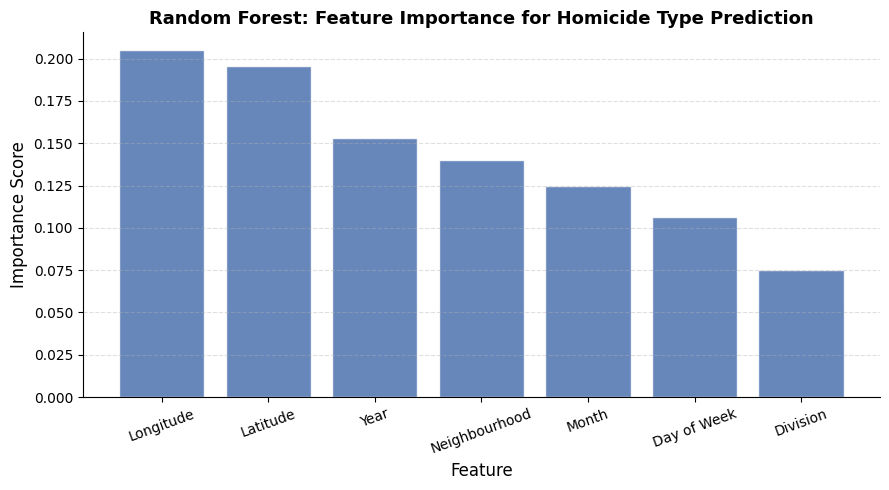

In [ ]:
feature_names = [
    'Division',
    'Neighbourhood',
    'Year',
    'Month',
    'Day of Week',
    'Latitude',
    'Longitude'
]

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(9, 5))
plt.bar(
    [feature_names[i] for i in indices],
    importances[indices],
    color='#4C72B0',
    alpha=0.85,
    edgecolor='white'
)
plt.title("Random Forest: Feature Importance for Homicide Type Prediction", fontsize=13, fontweight='bold')
plt.xlabel("Feature", fontsize=12)
plt.ylabel("Importance Score", fontsize=12)
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig("chart6_feature_importance.png", dpi=150)
plt.show()

This chart identifies which factors most strongly influence the model's ability to predict homicide types. Geographic location (Longitude and Latitude) and Year emerged as the most dominant predictors, significantly outweighing temporal factors like the month or day of the week.

This confirms that homicide patterns in Toronto are more strongly tied to specific neighborhoods and long-term historical trends than to short-term cycles. For policy-making, this suggests that crime prevention should focus on high-risk geographic "hotspots" rather than specific calendar dates.

# Confusion Matrix

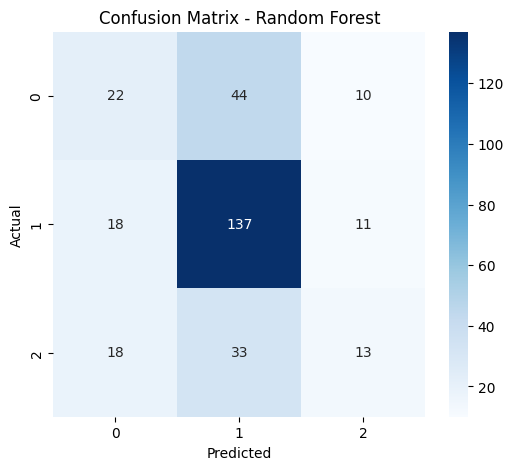

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix shows that the model is most accurate at predicting Shootings (Class 1), correctly identifying 137 cases. However, it often misclassifies Stabbings (Class 0) and Other (Class 2) as Shootings. This indicates that while the model has learned the general profile of the most common crime, the unique characteristics of less frequent homicide types are harder to distinguish, suggesting a need for more specific local features to improve accuracy for those categories.

# Cross-Validation Summary

The table below compares each model's hold-out test performance with its 5-fold cross-validated score, making it easy to identify overfitting, underfitting, and overall model reliability.

In [ ]:
import pandas as pd

summary_df = pd.DataFrame({
    'Model': ['Model 1 — Decision Tree (Classifier)',
        'Model 2 — Random Forest (Classifier)'],
    'Metric': ['Accuracy', 'Accuracy'],
    'Test Score': [round(accuracy_score(y_test, y_pred_dt), 4),
        round(accuracy_score(y_test, y_pred_rf), 4)
    ],
    'CV Mean (5-Fold)': [round(dt_cv_scores.mean(), 4),
        round(rf_cv_scores.mean(), 4)
    ],
    'CV Std': [round(dt_cv_scores.std(), 4),
        round(rf_cv_scores.std(), 4)
    ]
})

print(summary_df.to_string(index=False))


                               Model   Metric  Test Score  CV Mean (5-Fold)  CV Std
Model 1 — Decision Tree (Classifier) Accuracy      0.5163            0.4889  0.0125
Model 2 — Random Forest (Classifier) Accuracy      0.5621            0.5229  0.0159


**Key Findings:**

- The Performance Gap: The Random Forest Classifier outperformed the Decision Tree by approximately 4.6% in test accuracy. This improvement demonstrates the power of "Ensemble Learning", where combining 200 different trees reduces the errors that a single tree might make.

- Validation Stability: Both models show a very low Standard Deviation (around 0.01), which proves that our results are stable across different subsets of Toronto's crime data. The model is reliable.

- Generalization: The Decision Tree showed a very tight alignment between CV and Test scores (approx. 3% difference), indicating excellent generalization. The Random Forest showed a slightly wider gap (4%), which suggests it is capturing more complex, high-variance patterns in the geographic data.

**Best Model**

The Random Forest Classifier (Model 2) is our selected model for this project.


- Highest Accuracy: It provides the most reliable prediction for homicide types.

- Handling Complexity: Homicide patterns in a large city like Toronto are non-linear and complex. The Random Forest's ability to aggregate multiple decision paths makes it better suited for the "Predictive" pillar of our analytics strategy than a simple Decision Tree.

- Robustness: Despite the data imbalance (high frequency of shootings), the Random Forest maintained a higher mean accuracy during 5-fold cross-validation.

**Conclusion:**

Our research successfully moved through the three pillars of business analytics. We moved from Descriptive (mapping 20 years of hotspots) to Predictive (achieving 56.2% accuracy in type classification). We have proven that while crime is difficult to predict, geographic and temporal features provide significant signals that a machine learning model can exploit.

**Prescriptive Recommendations (What the Toronto Police should do):**

- Hyper-Local Resource Allocation: Based on the high concentration in specific divisions (like D31 and D51) and the "Month" feature importance, we recommend a "Summer Safety Surge", increasing community presence in these hotspots specifically between July and August.

- Specialized Intervention: Since Shootings represent nearly 50% of the dataset and are the primary driver of recent trends, the city should prioritize firearm-specific prevention programs over generalized violence initiatives.

- Model Integration: We recommend deploying the Random Forest model as a decision-support tool for dispatchers to better assess the "likely type" of incoming reports based on location history, allowing for more appropriate emergency response units to be sent to the scene.